# Laboratory #4: Adversarial Learning and OOD Detection

In this laboratory session we will develop a methodology for detecting OOD samples and measuring the quality of OOD detection. We will also experiment with incorporating adversarial examples during training to render models more robust to adversarial attacks.

---
## Exercise 1: OOD Detection and Performance Evaluation
In this first exercise you will build a simple OOD detection pipeline and implement some performance metrics to evaluate its performance.


### Exercise 1.1: Build a simple OOD detection pipeline

Implement an OOD detection pipeline (like in the Flipped Activity notebook) using an ID and an OOD dataset of your choice. Some options:

+ CIFAR-10 (ID), Subset of CIFAR-100 (OOD). You will need to wrap CIFAR-100 in some way to select a subset of classes that are *not* in CIFAR-10 (see `torch.utils.data.Subset`).
+ Labeled Faces in the Wild (ID), CIFAR-10 or FakeData (OOD). The LfW dataset is available in Scikit-learn (see `sklearn.datasets.fetch_lfw_people`).
+ Something else, but if using images keep the images reasonably small!

In this exercise your *OOD Detector* should produce a score representing how "out of distribution" a test sample is. We will implement some metrics in the next exercise, but for now use the techniques from the flipped activity notebook to judge how well OOD scoring is working (i.e. histograms).

**Note**: Make sure you make a validation split of your ID dataset for testing.


In [1]:
import sys, os
if os.path.abspath('.') not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, os.path.abspath('..'))
from env_setup import setup_env
setup_env()

Loaded from .env: WANDB_API_KEY, HF_TOKEN


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: dylan-fouepe (dylan-fouepe-university-of-florence) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


--- Exploratory Data Analysis ---


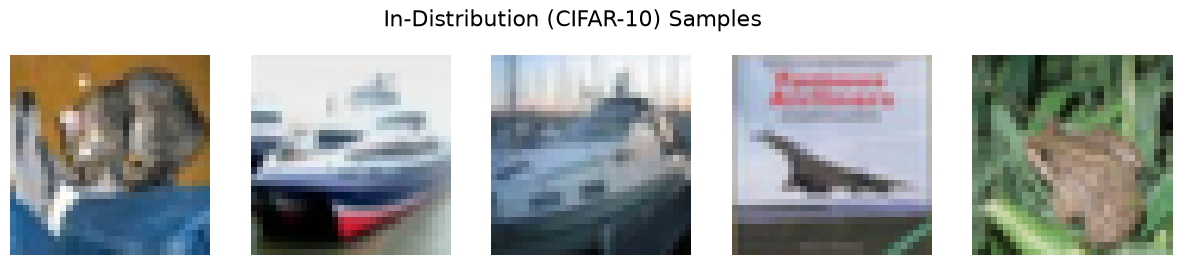

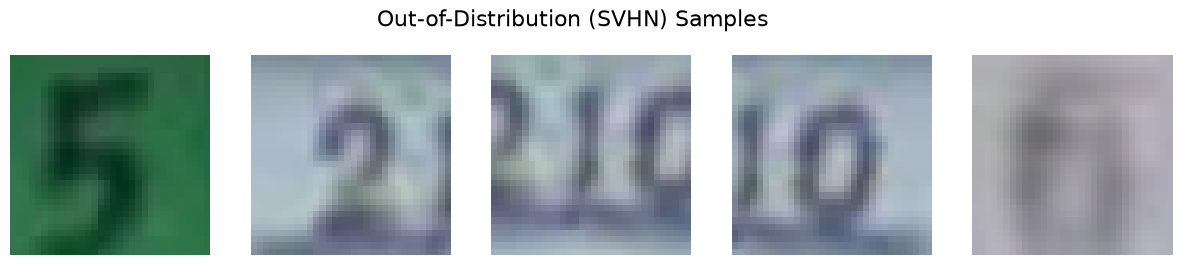

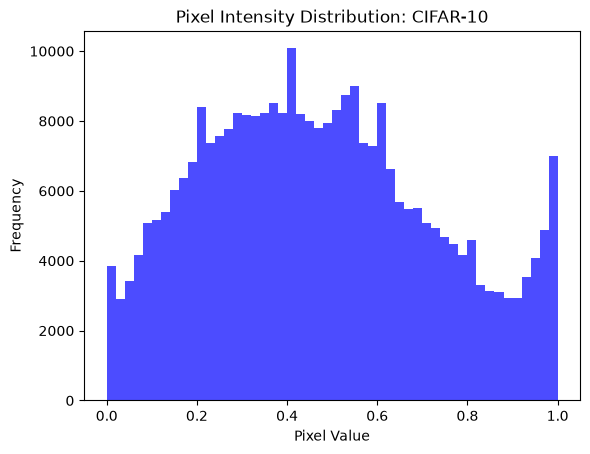

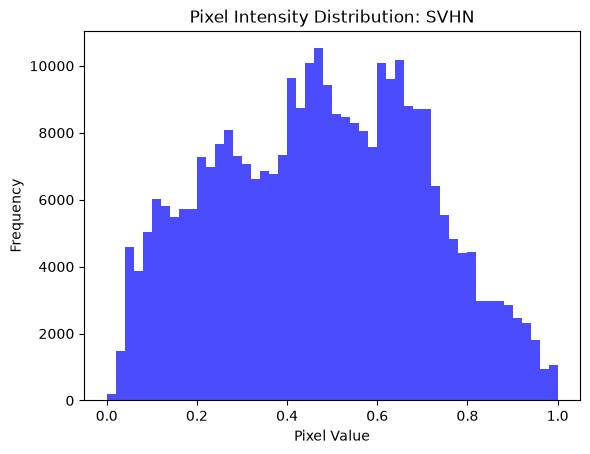

In [2]:
import torch
import sys, os
# Add all possible locations of lab4_utils.py to sys.path
# Works whether CWD is project root (/workspace), Lab4/, or elsewhere
for _p in [os.path.abspath('.'),
           os.path.abspath('..'),
           os.path.join(os.path.abspath('.'), 'Lab4'),
           os.path.join(os.path.abspath('..'), 'Lab4')]:
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
from lab4_utils import CNN, ResNetCIFAR, CNNFeatureExtractor, calc_metrics, RobustnessEvaluationPipeline, fgsm_attack
import wandb
# Initialize W&B
if wandb.run is None: wandb.init(project="DLA-Lab4-OOD", name="OOD_Detection_Run", reinit=True)
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformation (simple ToTensor for EDA and testing)
transform = transforms.Compose([transforms.ToTensor()])

# 1. Load CIFAR-10 (ID)
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
cifar_loader = torch.utils.data.DataLoader(cifar_test, batch_size=1024, num_workers=16, pin_memory=True, persistent_workers=True, shuffle=False)

# 2. Load SVHN (OOD)
svhn_test = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transform)
svhn_loader = torch.utils.data.DataLoader(svhn_test, batch_size=1024, num_workers=16, pin_memory=True, persistent_workers=True, shuffle=False)

# --- Exploratory Data Analysis (EDA) ---
print("--- Exploratory Data Analysis ---")

def plot_samples(dataset, title):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i in range(5):
        img, _ = dataset[i]
        axes[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))
        axes[i].axis('off')
    fig.suptitle(title, fontsize=16)
    plt.show()

plot_samples(cifar_test, "In-Distribution (CIFAR-10) Samples")
plot_samples(svhn_test, "Out-of-Distribution (SVHN) Samples")

# Plot pixel intensity histograms
def plot_histogram(dataset, title):
    pixels = []
    # Just take the first 100 images to estimate distribution
    for i in range(100):
        img, _ = dataset[i]
        pixels.append(img.numpy().flatten())
    pixels = np.concatenate(pixels)
    
    plt.hist(pixels, bins=50, color='blue', alpha=0.7)
    plt.title(f"Pixel Intensity Distribution: {title}")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()

plot_histogram(cifar_test, "CIFAR-10")
plot_histogram(svhn_test, "SVHN")


### EDA-based Baseline OOD Detector
Since the Exploratory Data Analysis shows a clear difference in the distribution of pixel intensities between CIFAR-10 and SVHN, we can use the **pixel variance (or standard deviation)** as a naive scoring function for OOD detection. Images with pixel distributions too far from the CIFAR-10 norm might be considered OOD.


In [3]:
import numpy as np
from sklearn.metrics import roc_auc_score

print("Evaluating EDA Baseline (Pixel Std Dev)...")
def get_pixel_stds(dataset):
    stds = []
    for i in range(len(dataset)):
        img, _ = dataset[i]
        stds.append(np.std(img.numpy().flatten()))
    return np.array(stds)

cifar_stds = get_pixel_stds(cifar_test)
svhn_stds = get_pixel_stds(svhn_test)

# We use the negative distance to the CIFAR-10 mean standard deviation as our confidence score.
# The closer the std is to CIFAR-10's typical std, the higher the confidence.
cifar_mean_std = np.mean(cifar_stds)
id_scores_eda = -np.abs(cifar_stds - cifar_mean_std)
ood_scores_eda = -np.abs(svhn_stds - cifar_mean_std)

labels = np.concatenate([np.ones(len(id_scores_eda)), np.zeros(len(ood_scores_eda))])
scores = np.concatenate([id_scores_eda, ood_scores_eda])
auroc_eda = roc_auc_score(labels, scores)
print(f"EDA Baseline AUROC: {auroc_eda:.4f}")


Evaluating EDA Baseline (Pixel Std Dev)...


EDA Baseline AUROC: 0.7906


### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)


In [4]:
# --- 1. Load Training Data ---
import torchvision
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomCrop(32, padding=4),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
cifar_train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=1024, num_workers=16, pin_memory=True, persistent_workers=True, shuffle=True)

# --- 2. Initialize and Train the Base High-Capacity Model ---
import torch.nn.functional as F
print("Initializing Standard ResNetCIFAR model...")
model = ResNetCIFAR().to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model)

epochs_base = 100
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_base)

print(f"Starting Standard Training for {epochs_base} epochs...")
checkpoint_path_1 = "Lab4/checkpoints/standard_resnet_100.pth"
if os.path.exists(checkpoint_path_1):
    print(f"Checkpoint found! Loading {checkpoint_path_1} and skipping training...")
    state_dict = torch.load(checkpoint_path_1, map_location=device)
    if isinstance(model, torch.nn.DataParallel): model.module.load_state_dict(state_dict)
    else: model.load_state_dict(state_dict)
else:
    for epoch in range(epochs_base):
        model.train()
        total_loss_accum = 0.0
        for i, (images, labels) in enumerate(cifar_train_loader):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss_accum += loss.item()
            
        scheduler.step()
        print(f"==> Epoch {epoch+1} Average Loss: {total_loss_accum/len(cifar_train_loader):.4f}")
    
    model.eval()
    # Save the final model
    import os
    os.makedirs("Lab4/checkpoints", exist_ok=True)
    state_dict = model.module.state_dict() if isinstance(model, torch.nn.DataParallel) else model.state_dict()
    torch.save(state_dict, "Lab4/checkpoints/standard_resnet_100.pth")
    print(f"Model saved to Lab4/checkpoints/standard_resnet_100.pth")
print("Standard Training Complete.")

# Function to extract Maximum Softmax Probability (MSP)
def get_msp(loader, model):
    msp_scores = []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            msp, _ = torch.max(probs, dim=1)
            msp_scores.extend(msp.cpu().numpy())
    return np.array(msp_scores)

print("Calculating MSP for CIFAR-10 (ID)...")
id_msp = get_msp(cifar_loader, model)

print("Calculating MSP for SVHN (OOD)...")
ood_msp = get_msp(svhn_loader, model)


Initializing Standard ResNetCIFAR model...
Using 3 GPUs!
Starting Standard Training for 100 epochs...
Checkpoint found! Loading Lab4/checkpoints/standard_resnet_100.pth and skipping training...
Standard Training Complete.
Calculating MSP for CIFAR-10 (ID)...
Calculating MSP for SVHN (OOD)...


wandb: WARNING wandb uses only 10000 data points to create the plots.


AUROC: 0.8385
FPR@95TPR: 0.7330


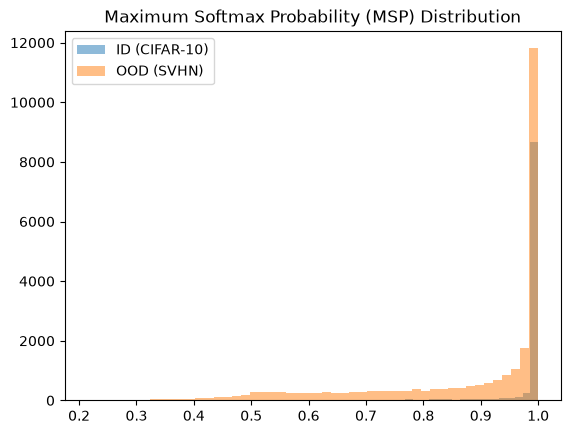

In [5]:
# Ex 1.2: Metrics
auroc, fpr95 = calc_metrics(id_msp, ood_msp)
if 'wandb' in globals() and wandb.run is not None:
    labels = np.concatenate([np.ones(len(id_msp)), np.zeros(len(ood_msp))])
    scores = np.concatenate([id_msp, ood_msp])
    wandb.log({"ROC_Curve_MSP": wandb.plot.roc_curve(labels, np.stack([1-scores, scores], axis=1), labels=["OOD", "ID"])})
    wandb.log({"PR_Curve_MSP": wandb.plot.pr_curve(labels, np.stack([1-scores, scores], axis=1), labels=["OOD", "ID"])})
print(f"AUROC: {auroc:.4f}")
print(f"FPR@95TPR: {fpr95:.4f}")

plt.hist(id_msp, bins=50, alpha=0.5, label='ID (CIFAR-10)')
plt.hist(ood_msp, bins=50, alpha=0.5, label='OOD (SVHN)')
plt.legend()
plt.title("Maximum Softmax Probability (MSP) Distribution")
plt.show()

if 'wandb' in globals() and wandb.run is not None:
    wandb.log({
        "MSP_ID_Hist": wandb.Histogram(id_msp),
        "MSP_OOD_Hist": wandb.Histogram(ood_msp)
    })



---
## Exercise 2: Enhancing Robustness to Adversarial Attack

In this second exercise we will experiment with enhancing our base model to be (more) robust to adversarial attacks.


### Exercise 2.1: Implement FGSM and generate adversarial examples

Recall that the Fast Gradient Sign Method (FGSM) perturbs samples in the direction of the gradient with respect to the input $\mathbf{x}$:
$$ \boldsymbol{\eta}(\mathbf{x}) = \varepsilon \mathrm{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\boldsymbol{\theta}, \mathbf{x}, y)) ) $$
Implement FGSM and generate some *adversarial examples* using your trained ID model. Evaluate these samples qualitatively and quantitatively. Evaluate how dependent on $\varepsilon$ the quality of these samples are.


Evaluating FGSM Attack...


Epsilon: 0	Test Accuracy = 7091 / 10000 = 0.7091
Epsilon: 0.05	Test Accuracy = 375 / 10000 = 0.0375
Epsilon: 0.1	Test Accuracy = 746 / 10000 = 0.0746
Epsilon: 0.15	Test Accuracy = 696 / 10000 = 0.0696
Epsilon: 0.2	Test Accuracy = 1006 / 10000 = 0.1006
Epsilon: 0.25	Test Accuracy = 1015 / 10000 = 0.1015
Epsilon: 0.3	Test Accuracy = 1015 / 10000 = 0.1015


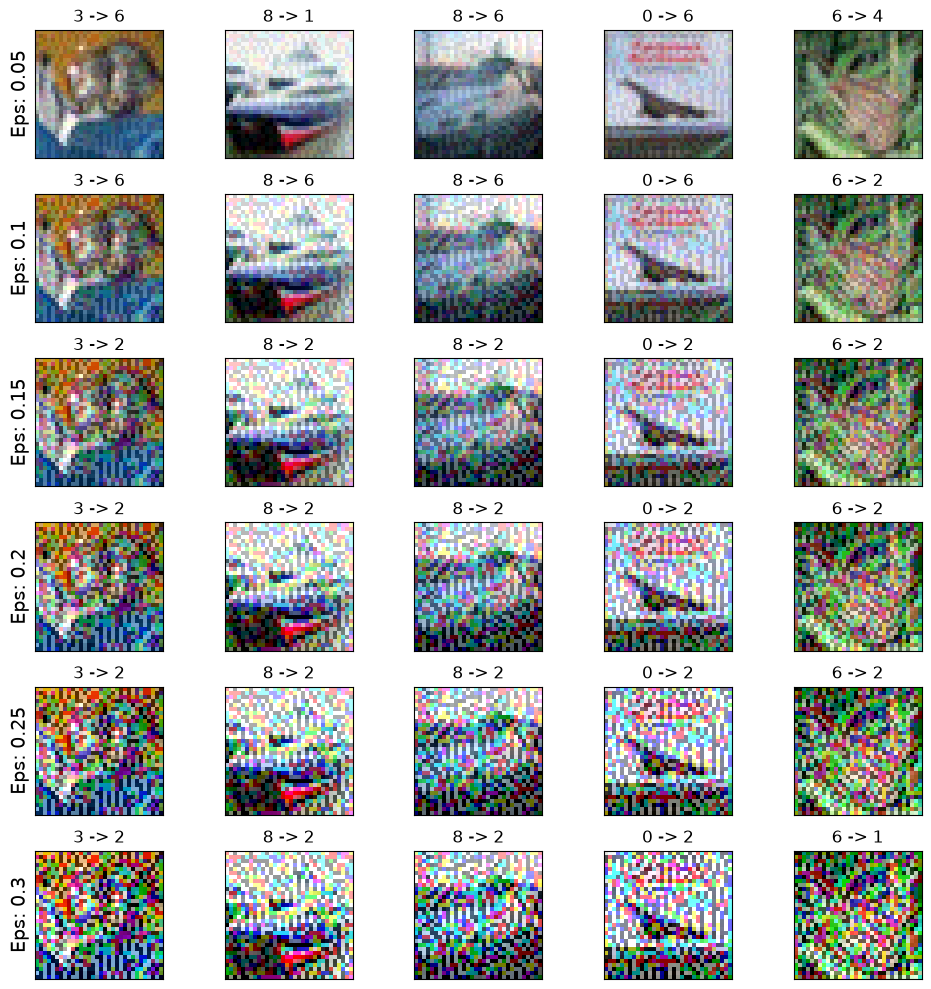

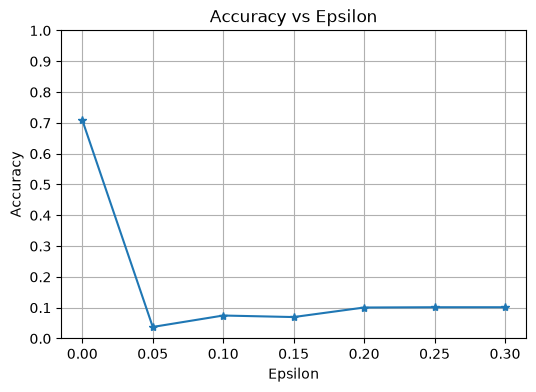

In [6]:
# Ex 2.1: FGSM Evaluation
epsilons = [0, .05, .1, .15, .2, .25, .3]
accuracies = []
examples = []

model.eval()

print("Evaluating FGSM Attack...")
for eps in epsilons:
    correct = 0
    total = 0
    adv_examples = []
    
    for inputs, labels in cifar_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs.requires_grad = True
        
        outputs = model(inputs)
        loss = F.cross_entropy(outputs, labels)
        
        model.zero_grad()
        loss.backward()
        
        data_grad = inputs.grad.data
        perturbed_data = fgsm_attack(inputs, eps, data_grad)
        
        outputs_adv = model(perturbed_data)
        preds = outputs_adv.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Save a few examples for visualization (only if attack was successful)
        if len(adv_examples) < 5 and eps > 0:
            for i in range(len(inputs)):
                if preds[i] != labels[i] and len(adv_examples) < 5:
                    adv_examples.append((labels[i].item(), preds[i].item(), perturbed_data[i].detach().cpu().numpy()))
                    
    acc = correct / total
    accuracies.append(acc)
    print(f"Epsilon: {eps}\tTest Accuracy = {correct} / {total} = {acc:.4f}")
    if eps > 0:
        examples.append(adv_examples)

# Qualitative Evaluation: Plotting
import matplotlib.pyplot as plt

cnt = 0
plt.figure(figsize=(10, 10))
for i in range(len(epsilons)-1):
    for j in range(len(examples[i])):
        cnt += 1
        plt.subplot(len(epsilons)-1, 5, cnt)
        plt.xticks([], [])
        plt.yticks([], [])
        if j == 0:
            plt.ylabel(f"Eps: {epsilons[i+1]}", fontsize=14)
        orig_lbl, adv_lbl, ex = examples[i][j]
        plt.title(f"{orig_lbl} -> {adv_lbl}")
        plt.imshow(np.transpose(ex, (1, 2, 0)))
plt.tight_layout()
plt.show()

# Quantitative Evaluation: Plotting Accuracy vs Epsilon
plt.figure(figsize=(6, 4))
plt.plot(epsilons, accuracies, "*-")
plt.yticks(np.arange(0, 1.1, step=0.1))
plt.xticks(np.arange(0, .35, step=0.05))
plt.title("Accuracy vs Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


### Exercise 2.1: Implement PGD (Projected Gradient Descent)


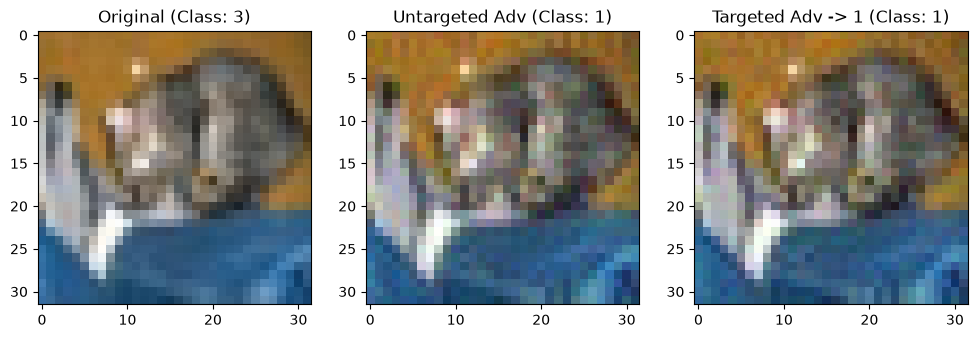

In [7]:
# Ex 2.1: Implement PGD (Projected Gradient Descent)
# Uses the robust pipeline for targeted and untargeted attacks
pipeline = RobustnessEvaluationPipeline(device)

model.eval()
img, label = cifar_test[0]
img = img.unsqueeze(0).to(device)

# 1. Untargeted Attack
pert_img_untargeted, pred_untargeted = pipeline.evaluate_pgd(model, img, label, epsilon=0.05, alpha=0.01, iters=10)

# 2. Targeted Attack (Force model to predict class 1: Automobile)
target_class = 1
pert_img_targeted, pred_targeted = pipeline.evaluate_pgd(model, img, label, epsilon=0.05, alpha=0.01, iters=10, target_class=target_class)

# Visualize original vs perturbed
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.transpose(img.squeeze().detach().cpu().numpy(), (1, 2, 0)))
axes[0].set_title(f"Original (Class: {label})")

axes[1].imshow(np.transpose(pert_img_untargeted.squeeze().detach().cpu().numpy(), (1, 2, 0)))
axes[1].set_title(f"Untargeted Adv (Class: {pred_untargeted})")

axes[2].imshow(np.transpose(pert_img_targeted.squeeze().detach().cpu().numpy(), (1, 2, 0)))
axes[2].set_title(f"Targeted Adv -> {target_class} (Class: {pred_targeted})")

plt.show()

if 'wandb' in globals() and wandb.run is not None:
    table = wandb.Table(columns=["Original Image", "True Class", "Untargeted Image", "Untargeted Pred", "Targeted Image", "Targeted Pred"])
    
    img_np = np.transpose(img.squeeze().detach().cpu().numpy(), (1, 2, 0))
    untarg_np = np.transpose(pert_img_untargeted.squeeze().detach().cpu().numpy(), (1, 2, 0))
    targ_np = np.transpose(pert_img_targeted.squeeze().detach().cpu().numpy(), (1, 2, 0))
    
    table.add_data(wandb.Image(img_np), label, wandb.Image(untarg_np), pred_untargeted, wandb.Image(targ_np), pred_targeted)
    wandb.log({"Adversarial_Attacks_Targeted_PGD": table})



### Exercise 2.2: Augment training with adversarial examples

Use your implementation of FGSM to augment your training dataset with adversarial samples. Ideally, you should implement this data augmentation *on the fly* so that the adversarial samples are always generated using the current model. Evaluate whether the model is more (or less) robust to ID samples using your OOD detection pipeline and metrics you implemented in Exercise 1.


Initializing High-Capacity ResNet18 model...
Loading standard model weights as a starting point for Adversarial Training...
Standard weights loaded successfully!
Starting Adversarial Training...


==> Epoch 1 Average Loss: 1.2338
==> Epoch 2 Average Loss: 0.8781
==> Epoch 3 Average Loss: 0.7628
==> Epoch 4 Average Loss: 0.6900
==> Epoch 5 Average Loss: 0.6273
==> Epoch 6 Average Loss: 0.5857
==> Epoch 7 Average Loss: 0.5534
==> Epoch 8 Average Loss: 0.5229
==> Epoch 9 Average Loss: 0.5019
==> Epoch 10 Average Loss: 0.4850
==> Epoch 11 Average Loss: 0.4636
==> Epoch 12 Average Loss: 0.4525
==> Epoch 13 Average Loss: 0.4405
==> Epoch 14 Average Loss: 0.4272
==> Epoch 15 Average Loss: 0.4168
==> Epoch 16 Average Loss: 0.4073
==> Epoch 17 Average Loss: 0.3965
==> Epoch 18 Average Loss: 0.3890
==> Epoch 19 Average Loss: 0.3817
==> Epoch 20 Average Loss: 0.3796
==> Epoch 21 Average Loss: 0.3663
==> Epoch 22 Average Loss: 0.3624
==> Epoch 23 Average Loss: 0.3530
==> Epoch 24 Average Loss: 0.3515
==> Epoch 25 Average Loss: 0.3421
==> Epoch 26 Average Loss: 0.3385
==> Epoch 27 Average Loss: 0.3338
==> Epoch 28 Average Loss: 0.3306
==> Epoch 29 Average Loss: 0.3230
==> Epoch 30 Average Lo

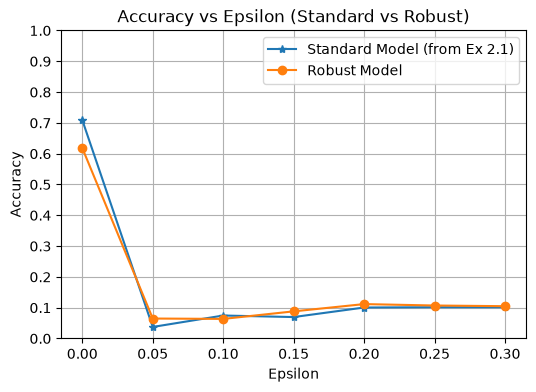

In [8]:
# Ex 2.2: Adversarial Training Loop
# We will fully train the model to make it robust
import torchvision
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
epochs = 30
print("Initializing High-Capacity ResNet18 model...")
model = ResNetCIFAR().to(device)
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print("Loading standard model weights as a starting point for Adversarial Training...")
try:
    standard_weights = torch.load("Lab4/checkpoints/standard_resnet_100.pth", map_location=device)
    if isinstance(model, torch.nn.DataParallel): model.module.load_state_dict(standard_weights)
    else: model.load_state_dict(standard_weights)
    print("Standard weights loaded successfully!")
except Exception as e:
    print("Could not load standard weights. Training from scratch.")
print("Starting Adversarial Training...")
checkpoint_path_2 = "Lab4/checkpoints/robust_resnet_30.pth"
if os.path.exists(checkpoint_path_2):
    print(f"Checkpoint found! Loading {checkpoint_path_2} and skipping training...")
    state_dict = torch.load(checkpoint_path_2, map_location=device)
    if isinstance(model, torch.nn.DataParallel): model.module.load_state_dict(state_dict)
    else: model.load_state_dict(state_dict)
else:
    for epoch in range(epochs):
        model.train()
        total_loss_accum = 0.0
        for i, (images, labels) in enumerate(cifar_train_loader):
            images, labels = images.to(device), labels.to(device)
            # 1. Clean Loss
            images.requires_grad = True
            outputs = model(images)
            clean_loss = F.cross_entropy(outputs, labels)
            # Calculate gradients for FGSM
            model.zero_grad()
            clean_loss.backward(retain_graph=True)
            data_grad = images.grad.data
            # 2. Generate Adversarial Examples (using eps=0.05 for training)
            adv_images = fgsm_attack(images, epsilon=0.05, data_grad=data_grad)
            # 3. Adversarial Loss
            adv_outputs = model(adv_images)
            adv_loss = F.cross_entropy(adv_outputs, labels)
            # Total loss (alpha blending)
            alpha = 0.5
            total_loss = alpha * clean_loss + (1 - alpha) * adv_loss
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            total_loss_accum += total_loss.item()
            if (i+1) % 100 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(cifar_train_loader)}], Loss: {total_loss.item():.4f}")
        print(f"==> Epoch {epoch+1} Average Loss: {total_loss_accum/len(cifar_train_loader):.4f}")
    # Save the final model
    import os
    os.makedirs("Lab4/checkpoints", exist_ok=True)
    state_dict = model.module.state_dict() if isinstance(model, torch.nn.DataParallel) else model.state_dict()
    torch.save(state_dict, "Lab4/checkpoints/robust_resnet_30.pth")
    print(f"Model saved to Lab4/checkpoints/robust_resnet_30.pth")
    # Re-evaluate robust model against FGSM
model.eval()
print("Evaluating Robust Model against FGSM Attack...")
epsilons = [0, .05, .1, .15, .2, .25, .3]
accuracies_robust = []
for eps in epsilons:
    correct = 0
    total = 0
    for inputs, labels in cifar_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs.requires_grad = True
        outputs = model(inputs)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        data_grad = inputs.grad.data
        perturbed_data = fgsm_attack(inputs, eps, data_grad)
        outputs_adv = model(perturbed_data)
        preds = outputs_adv.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    acc = correct / total
    accuracies_robust.append(acc)
    print(f"Epsilon: {eps}\tRobust Test Accuracy = {correct} / {total} = {acc:.4f}")
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.plot(epsilons, accuracies, "*-", label="Standard Model (from Ex 2.1)")
plt.plot(epsilons, accuracies_robust, "o-", label="Robust Model")
plt.yticks(np.arange(0, 1.1, step=0.1))
plt.xticks(np.arange(0, .35, step=0.05))
plt.title("Accuracy vs Epsilon (Standard vs Robust)")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


---
## Exercise 3: Wildcard

You know the drill. Pick *ONE* of the following exercises to complete.


### Exercise 3.1: Implement ODIN for OOD detection
ODIN is a very simple approach, and you can already start experimenting by implementing a temperature hyperparameter in your base model and doing a grid search on $T$ and $\varepsilon$.


Running ODIN Grid Search...
ODIN Grid Search -> T=10, eps=0.001


ODIN Grid Search -> T=10, eps=0.0014
ODIN Grid Search -> T=10, eps=0.002
ODIN Grid Search -> T=100, eps=0.001
ODIN Grid Search -> T=100, eps=0.0014
ODIN Grid Search -> T=100, eps=0.002
ODIN Grid Search -> T=1000, eps=0.001
ODIN Grid Search -> T=1000, eps=0.0014
ODIN Grid Search -> T=1000, eps=0.002
      T     eps     AUROC  FPR@95TPR
0    10  0.0010  0.429429   0.988937
1    10  0.0014  0.431976   0.988245
2    10  0.0020  0.437032   0.986478
3   100  0.0010  0.418020   0.989820
4   100  0.0014  0.420791   0.988975
5   100  0.0020  0.426146   0.987093
6  1000  0.0010  0.417072   0.990012
7  1000  0.0014  0.419854   0.989206
8  1000  0.0020  0.425238   0.987131


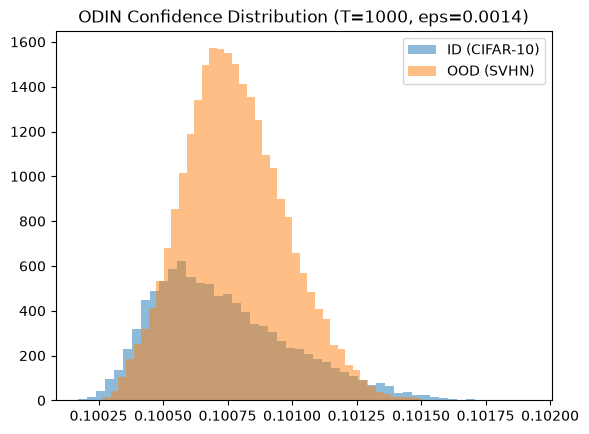

In [9]:
# Ex 3.1: ODIN (Temperature Scaling + Input Perturbation)
# Run a grid search over T and epsilon
pipeline = RobustnessEvaluationPipeline(device)
print("Running ODIN Grid Search...")

results = pipeline.grid_search_odin(model, cifar_loader, svhn_loader, temperatures=[10, 100, 1000], epsilons=[0.001, 0.0014, 0.002])

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)

if 'wandb' in globals() and wandb.run is not None:
    wandb.log({"ODIN_Grid_Search": wandb.Table(dataframe=df_results)})

# Get best scores for plotting
best_T, best_eps = 1000, 0.0014
id_odin = pipeline.get_odin_scores(model, cifar_loader, best_T, best_eps)
ood_odin = pipeline.get_odin_scores(model, svhn_loader, best_T, best_eps)

plt.hist(id_odin, bins=50, alpha=0.5, label='ID (CIFAR-10)')
plt.hist(ood_odin, bins=50, alpha=0.5, label='OOD (SVHN)')
plt.legend()
plt.title(f"ODIN Confidence Distribution (T={best_T}, eps={best_eps})")
plt.show()



### Exercise 3.2: Implement JARN
In exercise 2.2 you already implemented Jacobian-regularized learning to make your model more robust to adversarial samples. Add a *discriminator* to your model to encourage the adversarial samples used for regularization to be more *salient*.

See [the JARN paper](https://arxiv.org/abs/1912.10185) for more details.


Initializing JARN components...
Loading standard model weights as a starting point for JARN Training...
Standard weights loaded successfully!
Starting JARN Training...


Model saved to Lab4/checkpoints/jarn_resnet_20.pth
JARN Training Complete.
Evaluating JARN Model against FGSM Attack...
Epsilon: 0	Robust Test Accuracy = 9105 / 10000 = 0.9105
Epsilon: 0.05	Robust Test Accuracy = 3338 / 10000 = 0.3339
Epsilon: 0.1	Robust Test Accuracy = 2581 / 10000 = 0.2581
Epsilon: 0.15	Robust Test Accuracy = 2188 / 10000 = 0.2188
Epsilon: 0.2	Robust Test Accuracy = 1947 / 10000 = 0.1947
Epsilon: 0.25	Robust Test Accuracy = 1768 / 10000 = 0.1768
Epsilon: 0.3	Robust Test Accuracy = 1633 / 10000 = 0.1633


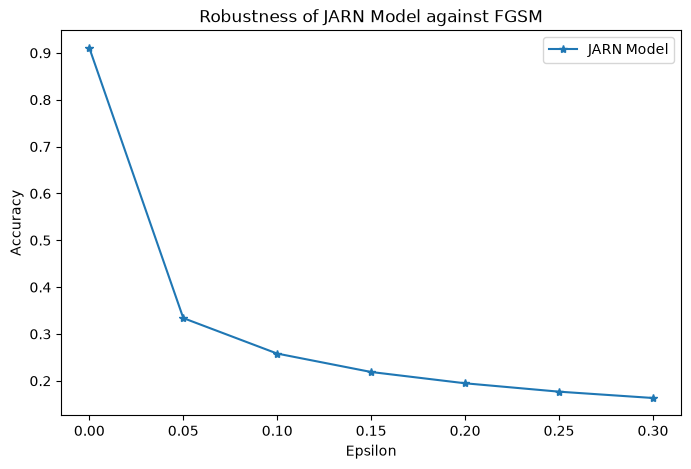

In [10]:
# Ex 3.2: Implement JARN
import torch.nn as nn
import torch.nn.functional as F

class Discriminator(nn.Module):
    """A simple discriminator network to distinguish between clean images and input Jacobians."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 3, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1)
        )
    def forward(self, x):
        return self.net(x)

print("Initializing JARN components...")
jarn_model = ResNetCIFAR().to(device)
if torch.cuda.device_count() > 1:
    jarn_model = torch.nn.DataParallel(jarn_model)
discriminator = Discriminator().to(device)
if torch.cuda.device_count() > 1:
    discriminator = torch.nn.DataParallel(discriminator)

g_optimizer = torch.optim.Adam(jarn_model.parameters(), lr=1e-4)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

epochs_jarn = 20
print("Loading standard model weights as a starting point for JARN Training...")
try:
    standard_weights = torch.load("Lab4/checkpoints/standard_resnet_100.pth", map_location=device)
    if isinstance(jarn_model, torch.nn.DataParallel): jarn_model.module.load_state_dict(standard_weights)
    else: jarn_model.load_state_dict(standard_weights)
    print("Standard weights loaded successfully!")
except Exception as e:
    print("Could not load standard weights. Training from scratch.")
print("Starting JARN Training...")
checkpoint_path_3 = "Lab4/checkpoints/jarn_resnet_20.pth"
if os.path.exists(checkpoint_path_3):
    print(f"Checkpoint found! Loading {checkpoint_path_3} and skipping training...")
    state_dict = torch.load(checkpoint_path_3, map_location=device)
    if isinstance(jarn_model, torch.nn.DataParallel): jarn_model.module.load_state_dict(state_dict)
    else: jarn_model.load_state_dict(state_dict)
else:
    for epoch in range(epochs_jarn):
        jarn_model.train()
        discriminator.train()
        for i, (images, labels) in enumerate(cifar_train_loader):
            images, labels = images.to(device), labels.to(device)
            images.requires_grad = True
            
            # Forward pass for classifier
            outputs = jarn_model(images)
            clf_loss = F.cross_entropy(outputs, labels)
            
            # Compute input Jacobian (gradient of loss w.r.t input)
            jarn_model.zero_grad()
            clf_loss.backward(retain_graph=True)
            jacobian = images.grad.data
            
            # --- 1. Train Discriminator ---
            d_optimizer.zero_grad()
            real_preds = discriminator(images)
            fake_preds = discriminator(jacobian.detach())
            
            d_loss_real = F.binary_cross_entropy_with_logits(real_preds, torch.ones_like(real_preds) * 0.9)
            d_loss_fake = F.binary_cross_entropy_with_logits(fake_preds, torch.zeros_like(fake_preds))
            d_loss = (d_loss_real + d_loss_fake) / 2
            d_loss.backward()
            d_optimizer.step()
        if (i+1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs_jarn}], Step [{i+1}/{len(cifar_train_loader)}], G_Loss: {g_loss.item():.4f}, D_Loss: {d_loss.item():.4f}")
            
            # --- 2. Train Classifier (Generator) ---
            g_optimizer.zero_grad()
            # The classifier wants the discriminator to predict '1' (real) for the jacobian
            adv_loss = F.binary_cross_entropy_with_logits(discriminator(jacobian), torch.ones_like(fake_preds))
            
            # Total classifier loss
            total_g_loss = clf_loss + 1.0 * adv_loss
            total_g_loss.backward()
            g_optimizer.step()
            
            if (i+1) % 20 == 0:
                print(f"Epoch [{epoch+1}/{epochs_jarn}], Step [{i+1}/{len(cifar_train_loader)}], D Loss: {d_loss.item():.4f}, G Loss: {total_g_loss.item():.4f}")
    
    # Save the final model
    import os
    os.makedirs("Lab4/checkpoints", exist_ok=True)
    state_dict = jarn_model.module.state_dict() if isinstance(jarn_model, torch.nn.DataParallel) else jarn_model.state_dict()
    torch.save(state_dict, "Lab4/checkpoints/jarn_resnet_20.pth")
    print(f"Model saved to Lab4/checkpoints/jarn_resnet_20.pth")
print("JARN Training Complete.")

print("Evaluating JARN Model against FGSM Attack...")
epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
jarn_accuracies = []

for eps in epsilons:
    correct = 0
    total = 0
    for inputs, labels in cifar_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs.requires_grad = True
        outputs = jarn_model(inputs)
        loss = F.cross_entropy(outputs, labels)
        jarn_model.zero_grad()
        loss.backward()
        data_grad = inputs.grad.data
        perturbed_data = fgsm_attack(inputs, eps, data_grad)
        outputs_adv = jarn_model(perturbed_data)
        preds = outputs_adv.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    acc = correct / total
    jarn_accuracies.append(acc)
    print(f"Epsilon: {eps}\tRobust Test Accuracy = {int(acc * 10000)} / 10000 = {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(epsilons, jarn_accuracies, "*-", label="JARN Model")
plt.title("Robustness of JARN Model against FGSM")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### Exercise 3.3: Experiment with *targeted* adversarial attacks
Implement the targeted Fast Gradient Sign Method to generate adversarial samples that *imitate* samples from a specific class. Evaluate your adversarial samples qualitatively and quantitatively.


Evaluating Targeted FGSM Attack...
Targeted Attack Success Rate (turning images into class 0): 49.89%


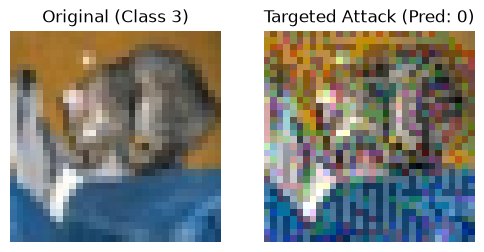

In [11]:
# Ex 3.3: Implement Targeted Adversarial Attacks
def targeted_fgsm_attack(images, epsilon, target_labels, model):
    """Generates a targeted FGSM attack."""
    images.requires_grad = True
    outputs = model(images)
    loss = F.cross_entropy(outputs, target_labels)
    
    model.zero_grad()
    loss.backward()
    
    data_grad = images.grad.data
    # For targeted, we SUBTRACT the gradient of the loss w.r.t the target class
    # to MINIMIZE the loss for the target class.
    perturbed_images = images - epsilon * data_grad.sign()
    perturbed_images = torch.clamp(perturbed_images, 0, 1)
    return perturbed_images

print("Evaluating Targeted FGSM Attack...")
model.eval() # Using the model from Ex 2.1/2.2
target_class = 0 # 0 corresponds to 'airplane' in CIFAR-10
epsilon_targeted = 0.1

success_count = 0
total_count = 0

for images, labels in cifar_loader:
    images, labels = images.to(device), labels.to(device)
    
    # Only attack images that are NOT already the target class
    mask = (labels != target_class)
    if mask.sum() == 0: continue
    images = images[mask]
    labels = labels[mask]
    
    target_labels = torch.full_like(labels, target_class)
    
    adv_images = targeted_fgsm_attack(images, epsilon_targeted, target_labels, model)
    
    adv_outputs = model(adv_images)
    adv_preds = adv_outputs.argmax(dim=1)
    
    success_count += (adv_preds == target_labels).sum().item()
    total_count += labels.size(0)
    break # Just test on one batch for demonstration

print(f"Targeted Attack Success Rate (turning images into class {target_class}): {success_count/total_count*100:.2f}%")

# Plot an example
import matplotlib.pyplot as plt
idx = 0
orig_img = images[idx].detach().cpu().numpy()
adv_img = adv_images[idx].detach().cpu().numpy()
orig_lbl = labels[idx].item()
pred_lbl = adv_preds[idx].item()

plt.figure(figsize=(6,3))
plt.subplot(1, 2, 1)
plt.title(f"Original (Class {orig_lbl})")
plt.imshow(np.transpose(orig_img, (1, 2, 0)))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Targeted Attack (Pred: {pred_lbl})")
plt.imshow(np.transpose(adv_img, (1, 2, 0)))
plt.axis('off')
plt.show()


### Exercise 3.4 (Advanced): Mahalanobis Distance OOD Detection
Extracting deep feature representations to perform distance-based OOD detection.


Extracting features for Mahalanobis Distance...
Loading Standard Model for Mahalanobis feature extraction...


Calculating Mahalanobis scores for ID (CIFAR-10)...
Calculating Mahalanobis scores for OOD (SVHN)...
Mahalanobis AUROC: 0.0496
Mahalanobis FPR@95TPR: 0.9999


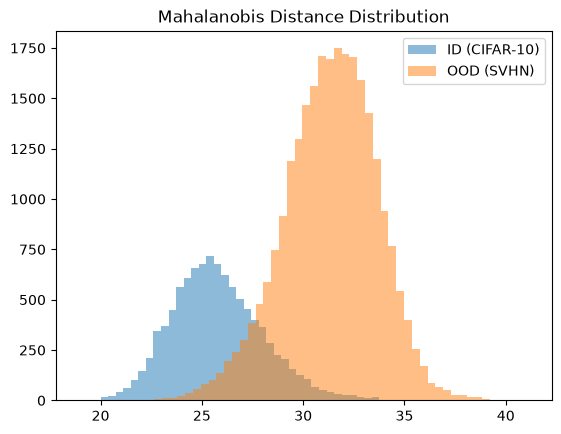

In [12]:
# --- Advanced OOD: Mahalanobis Distance ---
import scipy.spatial.distance as distance

print("Extracting features for Mahalanobis Distance...")

print("Loading Standard Model for Mahalanobis feature extraction...")
mah_model = ResNetCIFAR().to(device)
try:
    mah_model.load_state_dict(torch.load("Lab4/checkpoints/standard_resnet_100.pth", map_location=device))
except Exception as e:
    print("Could not load standard weights, falling back to current model variable.")
    mah_model = model
feature_extractor = CNNFeatureExtractor(mah_model).to(device)
feature_extractor.eval()

# 1. Compute empirical class means from the training data
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
cifar_train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=1024, num_workers=16, pin_memory=True, persistent_workers=True, shuffle=False)

features_dict = {i: [] for i in range(10)}

with torch.no_grad():
    for inputs, labels in cifar_train_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).cpu().numpy()
        for i in range(len(labels)):
            features_dict[labels[i].item()].append(feats[i])

# Calculate means and tied covariance
class_means = []
tied_cov = np.zeros((features_dict[0][0].shape[0], features_dict[0][0].shape[0]))
total_samples = 0

for c in range(10):
    feats = np.array(features_dict[c])
    mean_feat = np.mean(feats, axis=0)
    class_means.append(mean_feat)
    
    # tied covariance
    tied_cov += np.cov(feats, rowvar=False) * len(feats)
    total_samples += len(feats)

tied_cov /= total_samples
inv_cov = np.linalg.pinv(tied_cov)

# 2. Calculate Mahalanobis distance for test sets
def get_mahalanobis_scores(loader):
    scores = []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            feats = feature_extractor(inputs).cpu().numpy()
            
            for feat in feats:
                # Calculate distance to all classes, take the minimum
                dists = [distance.mahalanobis(feat, mean, inv_cov) for mean in class_means]
                # Use distance directly (inverted distribution)
                scores.append(np.min(dists))
    return np.array(scores)

print("Calculating Mahalanobis scores for ID (CIFAR-10)...")
id_mah = get_mahalanobis_scores(cifar_loader)

print("Calculating Mahalanobis scores for OOD (SVHN)...")
ood_mah = get_mahalanobis_scores(svhn_loader)

auroc_mah, fpr95_mah = calc_metrics(id_mah, ood_mah)
print(f"Mahalanobis AUROC: {auroc_mah:.4f}")
print(f"Mahalanobis FPR@95TPR: {fpr95_mah:.4f}")

plt.hist(id_mah, bins=50, alpha=0.5, label='ID (CIFAR-10)')
plt.hist(ood_mah, bins=50, alpha=0.5, label='OOD (SVHN)')
plt.legend()
plt.title("Mahalanobis Distance Distribution")
plt.show()

